# **Model Training For Helmet Detection**

# **Step 1: Loading Dataset**

In [1]:
import os
import cv2 # image processing task
import matplotlib.pyplot as plt

# Define dataset paths for Kaggle environment
train_path = "/kaggle/input/new-data3080/2nd dataset/train"
valid_path = "/kaggle/input/new-data3080/2nd dataset/valid"
test_path = "/kaggle/input/new-data3080/2nd dataset/test"

# **Step 2: Dataset Integrity Check**

In [2]:
def verify_files(image_folder, label_folder):
    """
    Verify that each image has a corresponding label file and vice versa.
    """
    image_files = set(os.listdir(image_folder))
    label_files = set(os.listdir(label_folder))

    # Extract base names without extensions
    image_base = {os.path.splitext(f)[0] for f in image_files}
    label_base = {os.path.splitext(f)[0] for f in label_files}

    # Find mismatched files
    missing_labels = image_base - label_base
    missing_images = label_base - image_base

    print(f"Missing Labels: {missing_labels}")
    print(f"Missing Images: {missing_images}")
    return missing_labels, missing_images

# Verify train, validation, and test datasets
print("Verifying Train Dataset:")
verify_files(os.path.join(train_path, "images"), os.path.join(train_path, "labels"))

print("\nVerifying Validation Dataset:")
verify_files(os.path.join(valid_path, "images"), os.path.join(valid_path, "labels"))

print("\nVerifying Test Dataset:")
verify_files(os.path.join(test_path, "images"), os.path.join(test_path, "labels"))


Verifying Train Dataset:
Missing Labels: set()
Missing Images: set()

Verifying Validation Dataset:
Missing Labels: set()
Missing Images: set()

Verifying Test Dataset:
Missing Labels: set()
Missing Images: set()


(set(), set())

# **Step 3: Visualizing Annotated Samples**

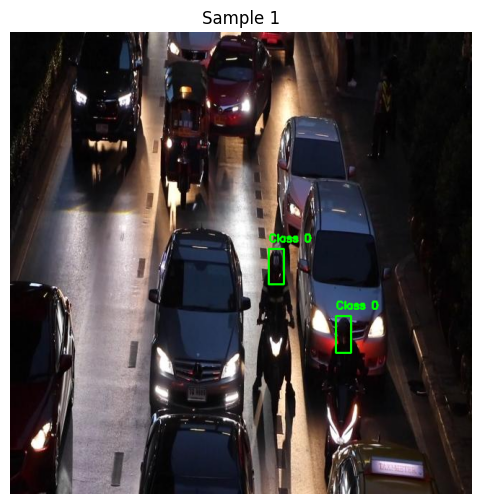

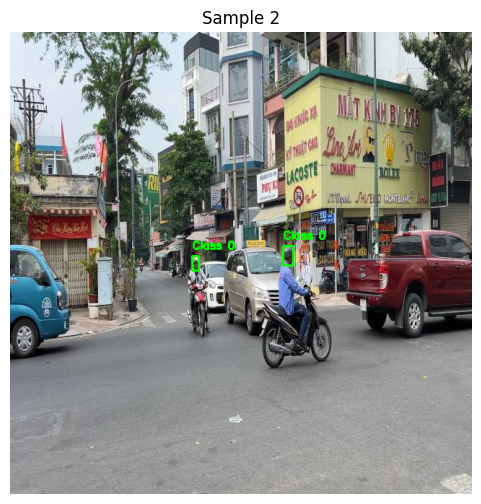

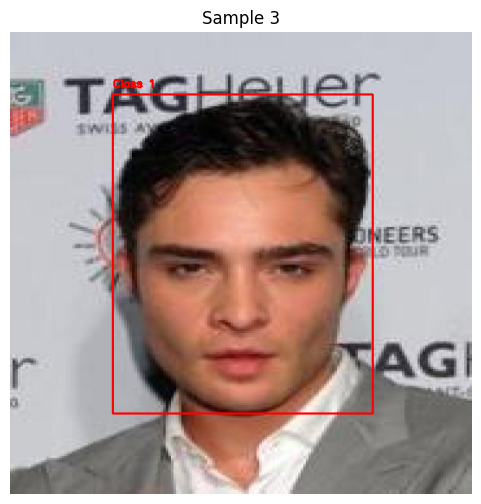

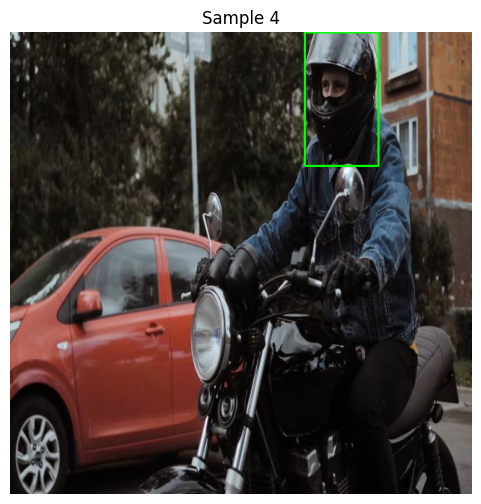

In [3]:
def visualize_annotations(image_folder, label_folder, num_samples=5):
    """
    Visualize a few images with their annotations.
    """
    image_files = os.listdir(image_folder)

    # Display a few annotated samples
    for i, image_file in enumerate(image_files[:num_samples]):
        # Load the image
        image_path = os.path.join(image_folder, image_file)
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Load the corresponding label
        label_file = os.path.join(label_folder, os.path.splitext(image_file)[0] + ".txt")
        with open(label_file, "r") as f:
            labels = f.readlines()

        # Draw bounding boxes and labels on the image
        for label in labels:
            label_data = label.strip().split()
            class_id, x_center, y_center, width, height = map(float, label_data)

            # Convert YOLO format to pixel coordinates
            img_h, img_w, _ = image.shape
            x_center, y_center, width, height = (
                x_center * img_w,
                y_center * img_h,
                width * img_w,
                height * img_h,
            )
            x_min = int(x_center - width / 2)
            y_min = int(y_center - height / 2)
            x_max = int(x_center + width / 2)
            y_max = int(y_center + height / 2)

            # Draw rectangle and label
            color = (0, 255, 0) if int(class_id) == 0 else (255, 0, 0)  # Helmet: Green, No Helmet: Red
            cv2.rectangle(image, (x_min, y_min), (x_max, y_max), color, 2)
            cv2.putText(image, f"Class {int(class_id)}", (x_min, y_min - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

        # Display the image
        plt.figure(figsize=(6, 6))
        plt.imshow(image)
        plt.axis("off")
        plt.title(f"Sample {i + 1}")
        plt.show()

# Visualize annotations from the training dataset
visualize_annotations(
    image_folder=os.path.join(train_path, "images"),
    label_folder=os.path.join(train_path, "labels"),
    num_samples=4
)


# **Step 4: Preprocessing**

**Step 4.1: Import Required Libraries**

In [4]:
import os
import cv2
import numpy as np
from tqdm import tqdm  # Import tqdm for progress bar


**Step 4.2: Data Preprocessing and Image Cropping for Helmet Detection Model**

In [5]:
def preprocess_and_save(image_folder, label_folder, output_folder, class_names):
    """
    Preprocess the dataset by cropping regions based on bounding boxes
    and saving the cropped images with proper labels.
    """
    os.makedirs(output_folder, exist_ok=True)

    # Create subfolders for each class
    for class_name in class_names:
        class_folder = os.path.join(output_folder, class_name)
        os.makedirs(class_folder, exist_ok=True)

    
    # Process each image
    for image_file in tqdm(os.listdir(image_folder), desc=f"Processing {image_folder}"):
        # Load image
        image_path = os.path.join(image_folder, image_file)
        image = cv2.imread(image_path)
        if image is None:
            print(f"Failed to load {image_path}")
            continue
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Load corresponding label
        label_file = os.path.join(label_folder, os.path.splitext(image_file)[0] + ".txt")
        if not os.path.exists(label_file):
            continue  # Skip if no label file

        with open(label_file, "r") as f:
            labels = f.readlines()

        
        # Extract and save each bounding box
        for idx, label in enumerate(labels):
            label_data = label.strip().split()

            # Use only the first 5 values for YOLO bounding box format
            if len(label_data) < 5:
                print(f"Invalid label format in {label_file}: {label}")
                continue

            class_id, x_center, y_center, width, height = map(float, label_data[:5])

            # Convert YOLO format to pixel coordinates
            img_h, img_w, _ = image.shape
            x_center, y_center, width, height = (
                x_center * img_w,
                y_center * img_h,
                width * img_w,
                height * img_h,
            )
            x_min = max(0, int(x_center - width / 2))
            y_min = max(0, int(y_center - height / 2))
            x_max = min(img_w, int(x_center + width / 2))
            y_max = min(img_h, int(y_center + height / 2))

            
            # Validate bounding box dimensions
            if x_min >= x_max or y_min >= y_max:
                print(f"Invalid bounding box in {label_file}: {label}")
                continue

            
            # Crop the region
            cropped_image = image[y_min:y_max, x_min:x_max]

            # Ensure the cropped image is not empty
            if cropped_image.size == 0:
                print(f"Empty crop for {label_file}: {label}")
                continue

            # Resize and normalize the image
            cropped_image = cv2.resize(cropped_image, (128, 128))
            cropped_image = cropped_image / 255.0  # Normalize to [0, 1]

            # Save the image
            class_folder = os.path.join(output_folder, class_names[int(class_id)])
            output_file_path = os.path.join(class_folder, f"{os.path.splitext(image_file)[0]}_{idx}.jpg")
            cv2.imwrite(output_file_path, (cropped_image * 255).astype(np.uint8))

**Step 4.3: Processing Training, Validation, and Test Datasets**

In [6]:
output_base_path = "/kaggle/working/processed_dataset"
class_names = ["helmet", "no-helmet", "notsure"]

print("Processing Training Data...")
preprocess_and_save(
    image_folder=os.path.join(train_path, "images"),
    label_folder=os.path.join(train_path, "labels"),
    output_folder=os.path.join(output_base_path, "train"),
    class_names=class_names,
)

print("Processing Validation Data...")
preprocess_and_save(
    image_folder=os.path.join(valid_path, "images"),
    label_folder=os.path.join(valid_path, "labels"),
    output_folder=os.path.join(output_base_path, "valid"),
    class_names=class_names,
)

print("Processing Test Data...")
preprocess_and_save(
    image_folder=os.path.join(test_path, "images"),
    label_folder=os.path.join(test_path, "labels"),
    output_folder=os.path.join(output_base_path, "test"),
    class_names=class_names,
)

Processing Training Data...


Processing /kaggle/input/new-data3080/2nd dataset/train/images: 100%|██████████| 3080/3080 [00:41<00:00, 73.43it/s]


Processing Validation Data...


Processing /kaggle/input/new-data3080/2nd dataset/valid/images: 100%|██████████| 858/858 [00:11<00:00, 76.26it/s]


Processing Test Data...


Processing /kaggle/input/new-data3080/2nd dataset/test/images:  66%|██████▋   | 429/646 [00:06<00:02, 84.95it/s]

Invalid bounding box in /kaggle/input/new-data3080/2nd dataset/test/labels/test46_mp4-0032_jpg.rf.854f1e63c2e529614be80320073060e5.txt: 0 0.30625 0.49921875 0.00078125 0.00078125



Processing /kaggle/input/new-data3080/2nd dataset/test/images: 100%|██████████| 646/646 [00:09<00:00, 71.47it/s]


# **Step 5: Build the Model**

In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_cnn_model(input_shape=(128, 128, 3), num_classes=3):
    model = models.Sequential([
        # Convolutional layers
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Flatten and fully connected layers
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')  # Output layer
    ])
    return model
model = build_cnn_model()
# Display the model summary
model.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │             387 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

# **Step 6: Compile the Model**

In [8]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# **Step 7: Data Augmentation and Data Generator**

**Step 7.1: Data Augmentation Setup**

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define data directories
train_dir = "/kaggle/working/processed_dataset/train"
valid_dir = "/kaggle/working/processed_dataset/valid"
test_dir = "/kaggle/working/processed_dataset/test"

# Data augmentation for training
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,  # Normalize to [0, 1]
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

# Validation and test data (no augmentation)
valid_datagen = ImageDataGenerator(rescale=1.0 / 255)
test_datagen = ImageDataGenerator(rescale=1.0 / 255)

**Step 7.2: Loading Training, Testing and Validation Data Using Data Generators**

In [10]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='sparse'
)
valid_generator = valid_datagen.flow_from_directory(
    valid_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='sparse'
)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(128, 128),
    batch_size=32,
    class_mode='sparse'
)


Found 13480 images belonging to 3 classes.
Found 3810 images belonging to 3 classes.
Found 2082 images belonging to 3 classes.


# **Step 8: Class Weight Calculation and Early Stopping Setup**

In [11]:
from sklearn.utils import class_weight
import numpy as np
from tensorflow.keras.callbacks import EarlyStopping

# Compute class weights
class_weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

# Define early stopping
early_stopping = EarlyStopping(
    monitor='val_loss',         # Monitor validation loss
    patience=10,                 # Stop training if val_loss doesn't improve for 10 consecutive epochs
    restore_best_weights=True   # Restore the best model weights
)


# **Step 9: Training and Saving the Model**

In [12]:
# Train the model
history=model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=50,
    class_weight=dict(enumerate(class_weights)),
    callbacks=[early_stopping]  # Add early stopping here
)

# Save the trained model
model.save("/kaggle/working/demo_new_helmet_detection_cnn.h5")


Epoch 1/50


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


422/422 ━━━━━━━━━━━━━━━━━━━━ 61s 129ms/step - accuracy: 0.6276 - loss: 1.1365 - val_accuracy: 0.8538 - val_loss: 0.3801
Epoch 2/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 52s 122ms/step - accuracy: 0.7738 - loss: 0.4813 - val_accuracy: 0.8766 - val_loss: 0.3495
Epoch 3/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 52s 120ms/step - accuracy: 0.7304 - loss: 0.5700 - val_accuracy: 0.7921 - val_loss: 0.4695
Epoch 4/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 51s 120ms/step - accuracy: 0.7495 - loss: 0.5326 - val_accuracy: 0.8486 - val_loss: 0.3966
Epoch 5/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 51s 119ms/step - accuracy: 0.7057 - loss: 0.9552 - val_accuracy: 0.8328 - val_loss: 0.5199
Epoch 6/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 51s 119ms/step - accuracy: 0.7400 - loss: 0.5171 - val_accuracy: 0.7801 - val_loss: 0.6011
Epoch 7/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 51s 119ms/step - accuracy: 0.7499 - loss: 0.5281 - val_accuracy: 0.7879 - val_loss: 0.6063
Epoch 8/50
422/422 ━━━━━━━━━━━━━━━━━━━━ 51s 119ms/step - accuracy: 0.7600 - loss: 0.5260 - val

# **Step 10: Evaluating Test Data**

In [13]:
# Evaluate on test data
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")


66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.8349 - loss: 0.4544
Test Accuracy: 83.33%


# **Step 11: Visualization**

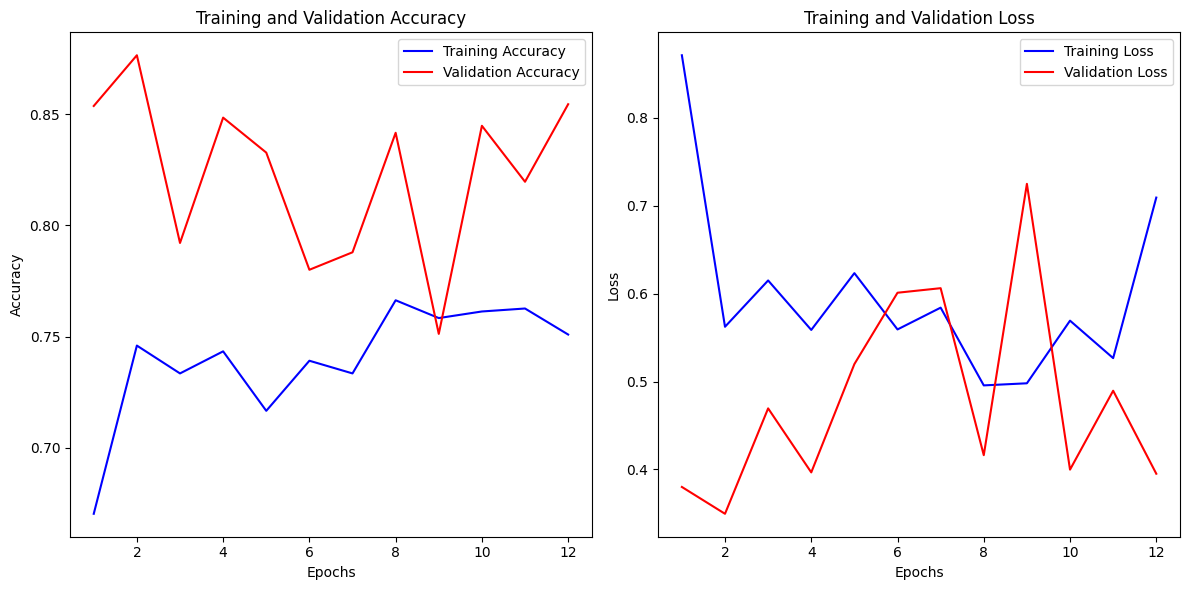

In [14]:
# Function to plot training history
import matplotlib.pyplot as plt

def plot_training_history(history):
    """
    Plots training and validation accuracy and loss curves.
    
    Parameters:
        history: The training history object from model.fit()
    """
    # Extract accuracy and loss
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    # Plot accuracy
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'b', label='Training Accuracy')
    plt.plot(epochs, val_acc, 'r', label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Plot loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'b', label='Training Loss')
    plt.plot(epochs, val_loss, 'r', label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

# Plot the training history
plot_training_history(history)
